<a href="https://colab.research.google.com/github/bommasanigunadeep92-cloud/disaster-response-emergency-coordination/blob/main/Python_code_representation_for_Disaster_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Disaster dataset (2).xlsx to Disaster dataset (2).xlsx


 Step-01: Import Required Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Step-02: Load the EM-DAT Disaster Dataset

The supplied EM-DAT dataset contains disaster-event records with information about disaster type, location, deaths, affected population, damage, and other characteristics. We can load it directly into a Pandas DataFrame.

In [ ]:
file_path = list(uploaded.keys())[0]

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 9407
Columns: 47


# Step-03: Prepare the EM-DAT DataFrame

In [ ]:
required_columns = [
    "DisNo.",
    "Disaster Type",
    "Disaster Subtype",
    "Country",
    "Region",
    "Latitude",
    "Longitude",
    "Start Year",
    "Start Month",
    "Start Day",
    "Total Deaths",
    "Total Affected",
    "Magnitude"
]

df = df[required_columns].copy()

df.head()

,DisNo.,Disaster Type,Disaster Subtype,Country,Region,Latitude,Longitude,Start Year,Start Month,Start Day,Total Deaths,Total Affected,Magnitude
0,2025-0303-ECU,Earthquake,Ground movement,Ecuador,Americas,1.084,-79.532,2025,4.0,25.0,NaN,8512.0,6.3
1,2026-0153-KEN,Flood,Flood (General),Kenya,Africa,NaN,NaN,2026,3.0,6.0,59.0,27.0,NaN
2,2025-0750-AFG,Earthquake,Ground movement,Afghanistan,Asia,34.519,70.734,2025,8.0,31.0,2200.0,1304600.0,6.0
3,2026-0305-AFG,Flood,Flood (General),Afghanistan,Asia,NaN,NaN,2026,4.0,24.0,18.0,73309.0,NaN
4,2024-0962-AGO,Epidemic,Bacterial disease,Angola,Africa,NaN,NaN,2025,1.0,7.0,776.0,27728.0,NaN


# Step 4 — Explore the Dataset

We now profile the supplied EM-DAT disaster dataset before creating visualizations. The objective is to understand its size, fields, data types, missing values, and numerical ranges.

Number of rows and columns

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9407
Number of columns: 13


Column names

In [ ]:
print(df.columns.tolist())

['DisNo.', 'Disaster Type', 'Disaster Subtype', 'Country', 'Region', 'Latitude', 'Longitude', 'Start Year', 'Start Month', 'Start Day', 'Total Deaths', 'Total Affected', 'Magnitude']


Dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DisNo.            9407 non-null   object 
 1   Disaster Type     9407 non-null   object 
 2   Disaster Subtype  9407 non-null   object 
 3   Country           9407 non-null   object 
 4   Region            9407 non-null   object 
 5   Latitude          948 non-null    float64
 6   Longitude         948 non-null    float64
 7   Start Year        9407 non-null   int64  
 8   Start Month       9352 non-null   float64
 9   Start Day         8649 non-null   float64
 10  Total Deaths      7495 non-null   float64
 11  Total Affected    7041 non-null   float64
 12  Magnitude         1626 non-null   float64
dtypes: float64(7), int64(1), object(5)
memory usage: 955.5+ KB


Statistical summary

In [ ]:
df.describe()

,Latitude,Longitude,Start Year,Start Month,Start Day,Total Deaths,Total Affected,Magnitude
count,948.000000,948.000000,9407.000000,9352.000000,8649.000000,7495.000000,7.041000e+03,1.626000e+03
mean,16.725236,42.947142,2017.678431,6.370723,15.249277,127.772248,3.704135e+05,7.591839e+04
std,22.182726,74.574853,4.819143,3.396446,9.039272,2790.593086,4.757663e+06,1.053680e+06
min,-52.825600,-124.692500,2010.000000,1.000000,1.000000,1.000000,1.000000e+00,-5.500000e+01
25%,1.090750,4.177250,2013.000000,3.000000,7.000000,8.000000,7.600000e+01,7.100000e+00
50%,20.175500,54.927000,2018.000000,7.000000,15.000000,16.000000,2.035000e+03,1.385000e+02
75%,35.400000,102.566000,2022.000000,9.000000,23.000000,32.000000,2.714000e+04,1.417475e+04
max,63.629590,178.080000,2026.000000,12.000000,31.000000,222570.000000,3.300000e+08,4.000000e+07


Check missing values

In [ ]:
df.isnull().sum()

,0
DisNo.,0
Disaster Type,0
Disaster Subtype,0
Country,0
Region,0
Latitude,8459
Longitude,8459
Start Year,0
Start Month,55
Start Day,758


# Step 5 — Create Disaster Date

In [ ]:
df["Start Date"] = pd.to_datetime(
    dict(
        year=df["Start Year"],
        month=df["Start Month"].fillna(1),
        day=df["Start Day"].fillna(1)
    ),
    errors="coerce"
)

date_min = df["Start Date"].min()
date_max = df["Start Date"].max()

print("Date range:", date_min, "to", date_max)

df.head()

Date range: 2010-01-01 00:00:00 to 2026-11-10 00:00:00


,DisNo.,Disaster Type,Disaster Subtype,Country,Region,Latitude,Longitude,Start Year,Start Month,Start Day,Total Deaths,Total Affected,Magnitude,Start Date
0,2025-0303-ECU,Earthquake,Ground movement,Ecuador,Americas,1.084,-79.532,2025,4.0,25.0,NaN,8512.0,6.3,2025-04-25
1,2026-0153-KEN,Flood,Flood (General),Kenya,Africa,NaN,NaN,2026,3.0,6.0,59.0,27.0,NaN,2026-03-06
2,2025-0750-AFG,Earthquake,Ground movement,Afghanistan,Asia,34.519,70.734,2025,8.0,31.0,2200.0,1304600.0,6.0,2025-08-31
3,2026-0305-AFG,Flood,Flood (General),Afghanistan,Asia,NaN,NaN,2026,4.0,24.0,18.0,73309.0,NaN,2026-04-24
4,2024-0962-AGO,Epidemic,Bacterial disease,Angola,Africa,NaN,NaN,2025,1.0,7.0,776.0,27728.0,NaN,2025-01-07


# Step 6 — Create Disaster Type Categories

For the visualizations, create meaningful disaster categories.

In [ ]:
disaster_counts = (
    df["Disaster Type"]
    .value_counts()
)

print(disaster_counts)

Disaster Type
Flood                               2595
Storm                               1873
Road                                1023
Water                                669
Earthquake                           421
Extreme temperature                  353
Epidemic                             336
Mass movement (wet)                  313
Fire (Miscellaneous)                 273
Drought                              253
Air                                  210
Wildfire                             210
Explosion (Industrial)               155
Rail                                 113
Collapse (Industrial)                104
Miscellaneous accident (General)     101
Collapse (Miscellaneous)              84
Explosion (Miscellaneous)             83
Volcanic activity                     76
Fire (Industrial)                     59
Industrial accident (General)         43
Gas leak                              16
Infestation                           11
Chemical spill                         8
Gl

# Task 1(a) — Flawed Bar Chart

Rule being broken:

Do not truncate the quantitative axis in a way that exaggerates differences.

Here, we intentionally start the y-axis above zero.

# Step 7 — Count Disasters by Disaster Type

In [ ]:
disaster_counts = (
    df["Disaster Type"]
    .value_counts()
)

print(disaster_counts)

Disaster Type
Flood                               2595
Storm                               1873
Road                                1023
Water                                669
Earthquake                           421
Extreme temperature                  353
Epidemic                             336
Mass movement (wet)                  313
Fire (Miscellaneous)                 273
Drought                              253
Air                                  210
Wildfire                             210
Explosion (Industrial)               155
Rail                                 113
Collapse (Industrial)                104
Miscellaneous accident (General)     101
Collapse (Miscellaneous)              84
Explosion (Miscellaneous)             83
Volcanic activity                     76
Fire (Industrial)                     59
Industrial accident (General)         43
Gas leak                              16
Infestation                           11
Chemical spill                         8
Gl

# Step 8 — Create the Intentionally Misleading Bar Chart

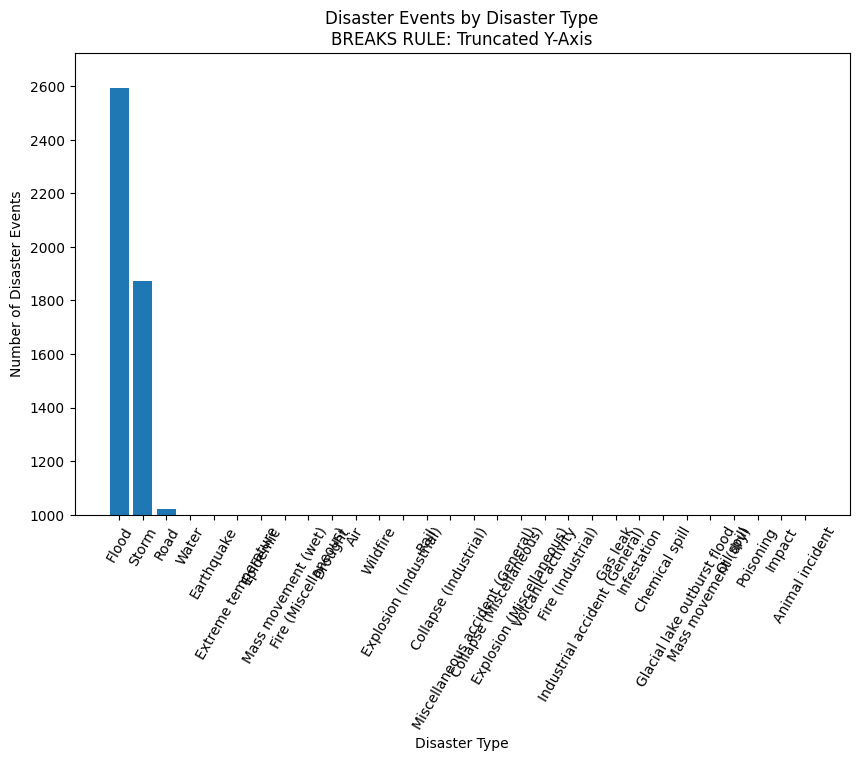

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    disaster_counts.index.astype(str),
    disaster_counts.values
)

plt.ylim(bottom=1000)

plt.xticks(rotation=60)

plt.title(
    "Disaster Events by Disaster Type\n"
    "BREAKS RULE: Truncated Y-Axis"
)

plt.xlabel("Disaster Type")
plt.ylabel("Number of Disaster Events")

plt.show()

# Task 1(b) — Flawed Pie Chart

In [ ]:
# Step 9 — Extract Country

In [ ]:
country_counts = (
    df["Country"]
    .value_counts()
)

print(country_counts.head(15))

Country
China                               601
India                               468
United States of America            461
Indonesia                           358
Philippines                         308
Pakistan                            203
Mexico                              182
Democratic Republic of the Congo    177
Nigeria                             177
Brazil                              176
Peru                                157
Viet Nam                            151
Russian Federation                  148
Bangladesh                          140
Colombia                            139
Name: count, dtype: int64


# Step 10 — Select 10+ Countries

In [ ]:
top_countries = country_counts.head(12)

print(top_countries)

Country
China                               601
India                               468
United States of America            461
Indonesia                           358
Philippines                         308
Pakistan                            203
Mexico                              182
Democratic Republic of the Congo    177
Nigeria                             177
Brazil                              176
Peru                                157
Viet Nam                            151
Name: count, dtype: int64


# Step 11 — Randomize the Category Order

In [ ]:
random_countries = top_countries.sample(
    frac=1,
    random_state=42
)

print(random_countries)

Country
Peru                                157
Brazil                              176
China                               601
Nigeria                             177
Pakistan                            203
United States of America            461
India                               468
Viet Nam                            151
Philippines                         308
Democratic Republic of the Congo    177
Indonesia                           358
Mexico                              182
Name: count, dtype: int64


# Step 12 — Create the Intentionally Flawed Pie Chart

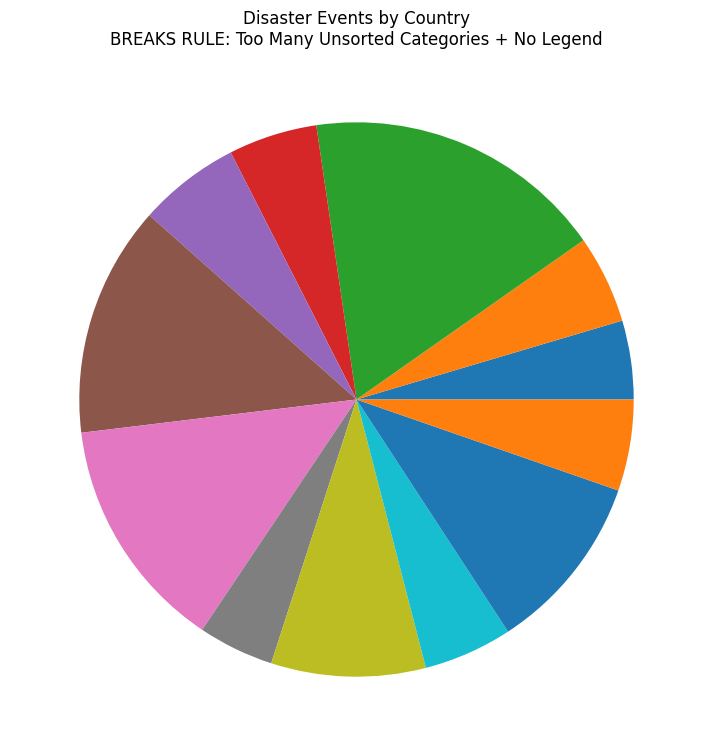

In [ ]:
plt.figure(figsize=(9, 9))

plt.pie(
    random_countries.values
)

plt.title(
    "Disaster Events by Country\n"
    "BREAKS RULE: Too Many Unsorted Categories + No Legend"
)

plt.show()

# Task 1(c) — Flawed Scatter Plot

Rules being broken:

1. No axis labels.
2. No units.
3. Rainbow/jet colormap.

We will plot:

X-axis → Total Deaths

Y-axis → Total Affected

In [ ]:
scatter_df = df.dropna(
    subset=["Total Deaths", "Total Affected"]
)

print("Rows available for scatter plot:", len(scatter_df))
print("Columns:", scatter_df.columns.tolist())

scatter_df.head()

Rows available for scatter plot: 5443
Columns: ['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
1,2026-0153-KEN,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-09,2026-05-15
2,2025-0750-AFG,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,GLIDE:EQ-2025-000153,NaN,AFG,...,NaN,NaN,NaN,180000.0,180000.0,100.0,NaN,NaN,2025-09-01,2026-05-15
3,2026-0305-AFG,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,AFG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-04,2026-05-11
4,2024-0962-AGO,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,GLIDE:EP-2025-000013,Cholera,AGO,...,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,2025-01-17,2026-05-15
6,2026-0174-SYR,No,nat-met-sto-sev,Natural,Meteorological,Storm,Severe weather,NaN,NaN,SYR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-18,2026-05-15


# Step 13 — Create the Intentionally Flawed Scatter Plot

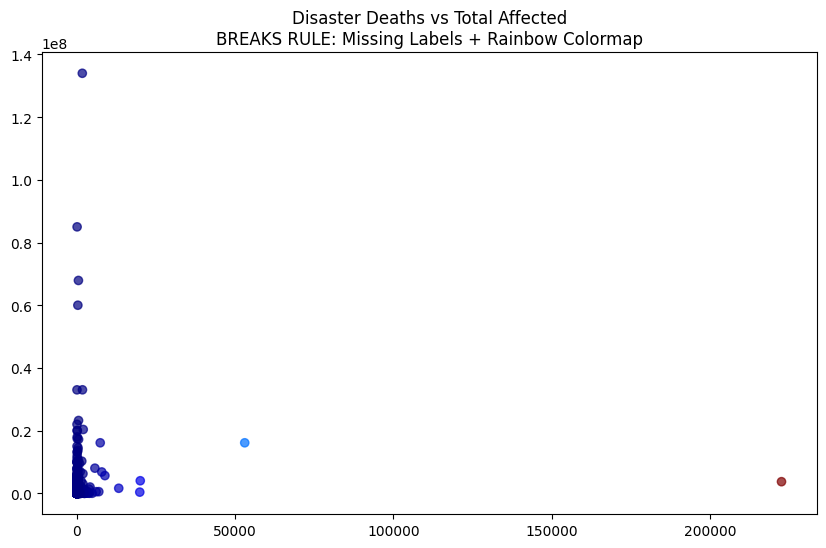

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_df["Total Deaths"],
    scatter_df["Total Affected"],
    c=scatter_df["Total Deaths"],
    cmap="jet",
    alpha=0.7
)

plt.title(
    "Disaster Deaths vs Total Affected\n"
    "BREAKS RULE: Missing Labels + Rainbow Colormap"
)

plt.show()

# Task 2(a) — Correct the Bar Chart

Problem

The previous chart used: y=1000

Fix

Use a zero baseline.

# Step 14 — Create the Corrected Bar Chart

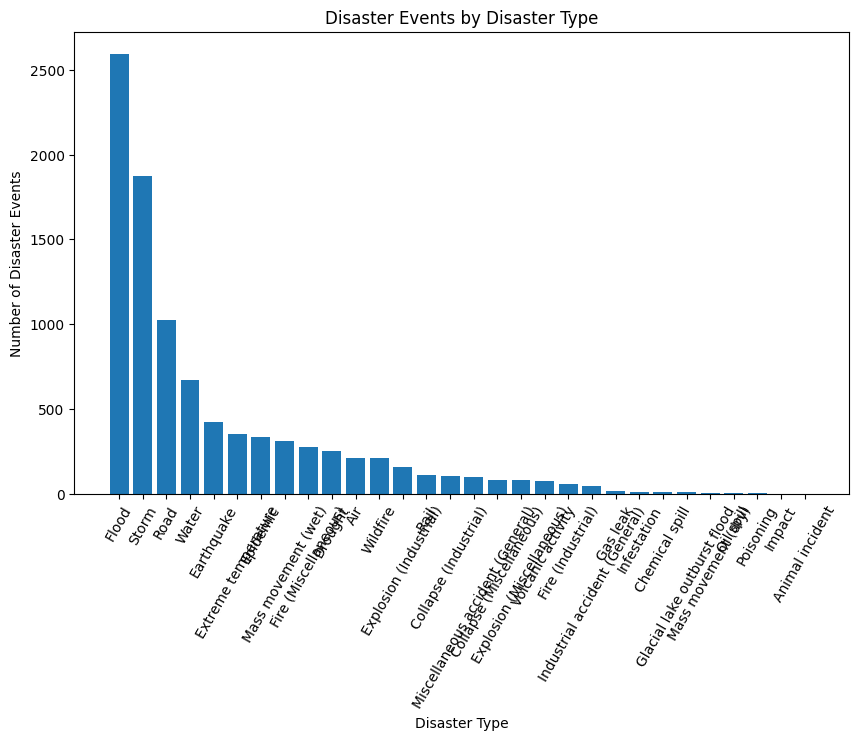

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    disaster_counts.index.astype(str),
    disaster_counts.values
)

plt.ylim(bottom=0)

plt.xticks(rotation=60)

plt.title("Disaster Events by Disaster Type")

plt.xlabel("Disaster Type")
plt.ylabel("Number of Disaster Events")

plt.show()

# Step 15 — Add Data Labels

Adding the values makes the chart easier to interpret.

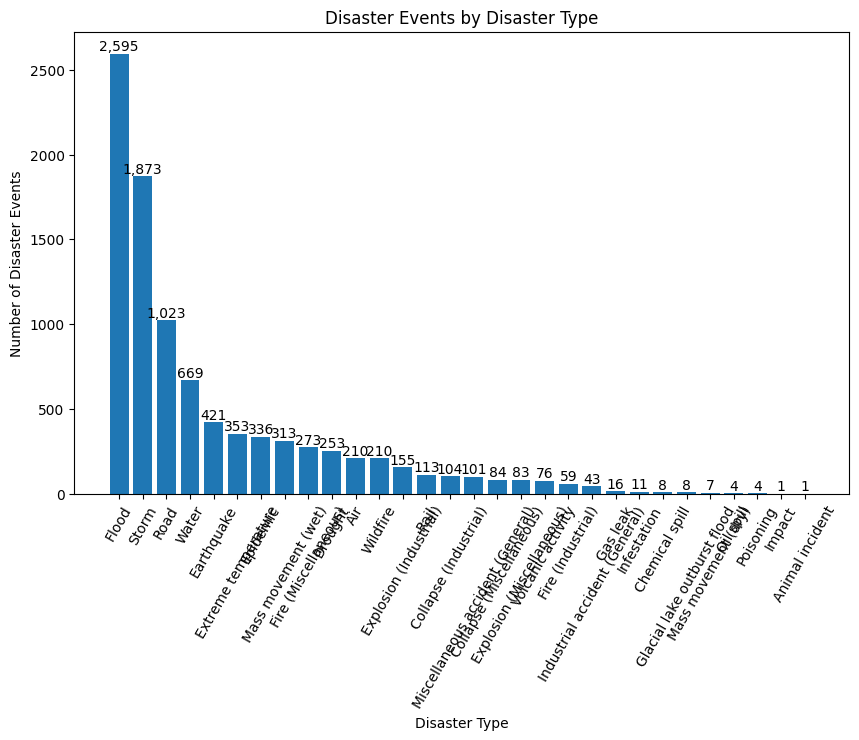

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    disaster_counts.index.astype(str),
    disaster_counts.values
)

plt.ylim(bottom=0)

plt.xticks(rotation=60)

plt.title("Disaster Events by Disaster Type")

plt.xlabel("Disaster Type")
plt.ylabel("Number of Disaster Events")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.show()

# Task 2(b) — Redesign the Pie Chart

The original pie chart had:

1. 12 categories
2. random order
3. no legend

We will now:

1. Reduce the categories.
2. Sort them by size.
3. Add labels/legend.

We will create six major disaster-type categories.

# Step 16 — Create Six Disaster Categories

In [ ]:
top6_disaster_types = (
    df["Disaster Type"]
    .value_counts()
    .head(6)
)

print(top6_disaster_types)

Disaster Type
Flood                  2595
Storm                  1873
Road                   1023
Water                   669
Earthquake              421
Extreme temperature     353
Name: count, dtype: int64


# Step 17 — Count and Sort the Categories

In [ ]:
disaster_type_counts = (
    top6_disaster_types
    .sort_values(ascending=False)
)

print(disaster_type_counts)

Disaster Type
Flood                  2595
Storm                  1873
Road                   1023
Water                   669
Earthquake              421
Extreme temperature     353
Name: count, dtype: int64


The result is now sorted from largest to smallest.

# Step 18 — Create the Corrected Pie Chart

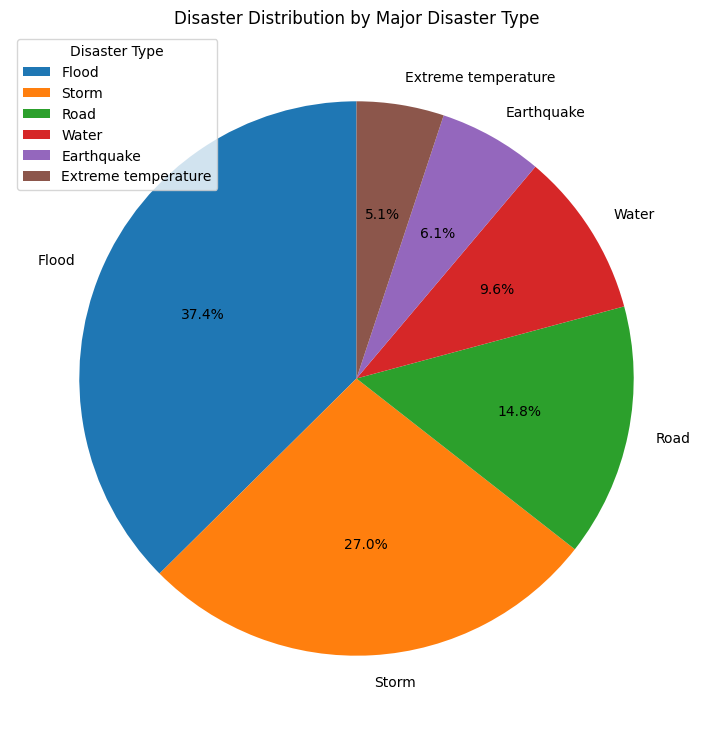

In [ ]:
plt.figure(figsize=(9, 9))

plt.pie(
    disaster_type_counts.values,
    labels=disaster_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Disaster Distribution by Major Disaster Type")

plt.legend(
    title="Disaster Type",
    loc="best"
)

plt.show()

# Task 2(c) — Correct the Scatter Plot

The original scatter plot had:

cmap="jet"

and no axis labels or units.

We will fix both problems.

We will plot:

X-axis → Total Deaths

Y-axis → Total Affected

Step 19 — Create the Corrected Scatter Plot

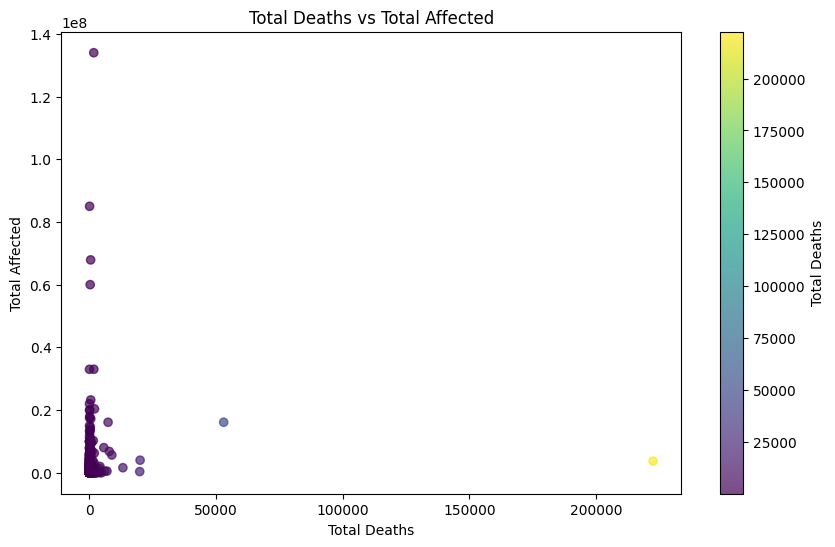

In [ ]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    scatter_df["Total Deaths"],
    scatter_df["Total Affected"],
    c=scatter_df["Total Deaths"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Total Deaths")
plt.ylabel("Total Affected")

plt.title("Total Deaths vs Total Affected")

plt.colorbar(
    scatter,
    label="Total Deaths"
)

plt.show()

# Step 20 — Add a Data-Source Caption

The final requirement is to make the chart publication-ready by adding a one-line data-source caption.

For this project, the source is the EM-DAT International Disaster Database.

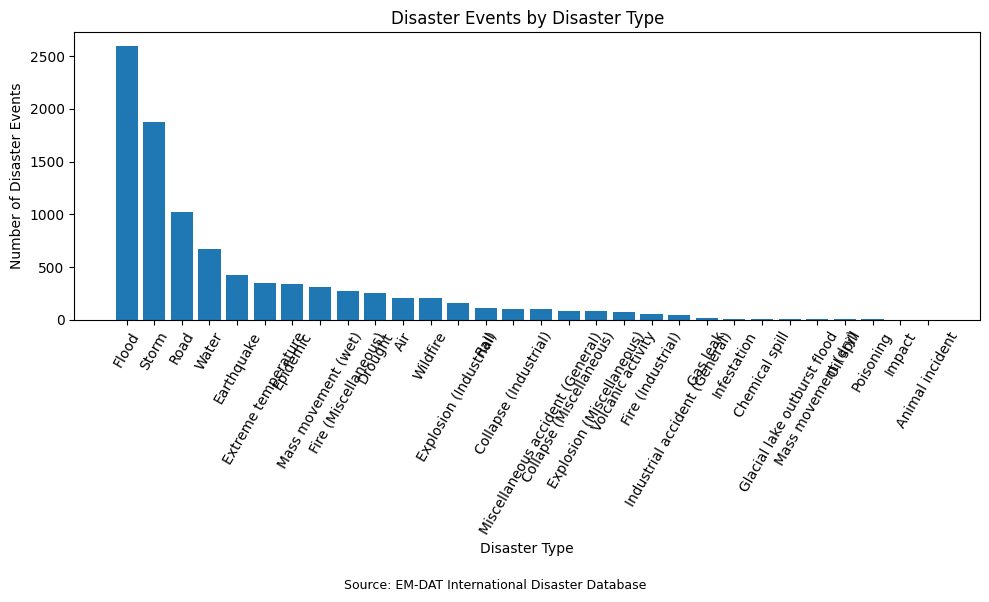

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    disaster_counts.index.astype(str),
    disaster_counts.values
)

ax.set_ylim(bottom=0)

ax.set_title("Disaster Events by Disaster Type")

ax.set_xlabel("Disaster Type")

ax.set_ylabel("Number of Disaster Events")

ax.tick_params(axis="x", rotation=60)

fig.text(
    0.5,
    0.01,
    "Source: EM-DAT International Disaster Database",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.show()